<a href="https://colab.research.google.com/github/harika-1296/SCT_ML_02/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

Load dataset

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Basic Data Information

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000

Data Visualization

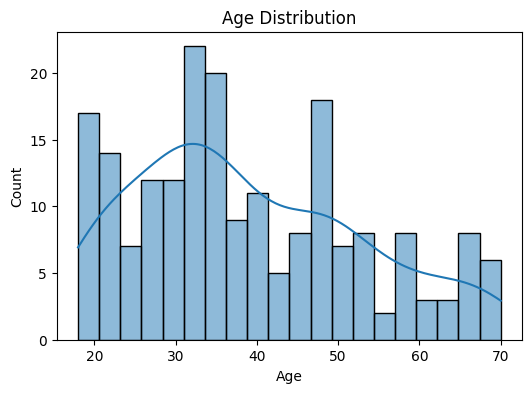

In [4]:
# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

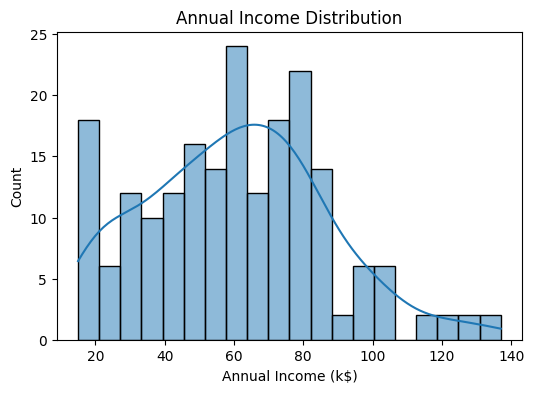

In [5]:
# Annual Income Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

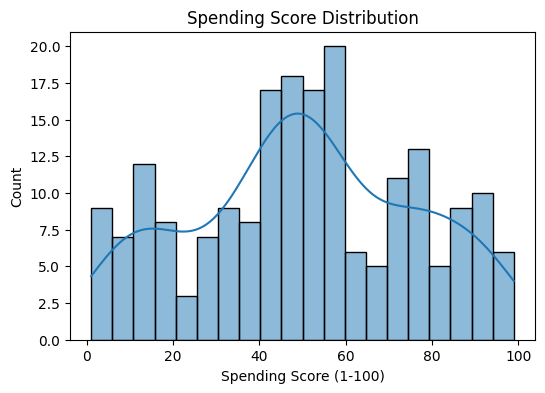

In [6]:
# Spending Score Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

Select Features For Clustering

In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Feature Scaling

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


Find Optimal Number of Clusters (Elbow Method)

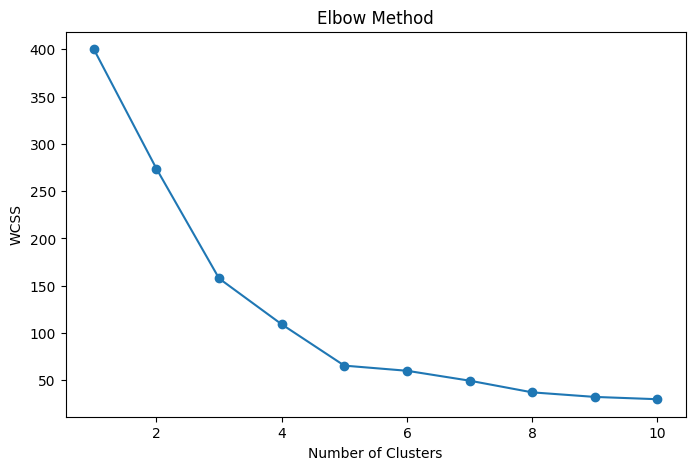

In [9]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Train K-Means Model

In [10]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

Add Cluster Labels

In [11]:
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Visualize Customer Segments

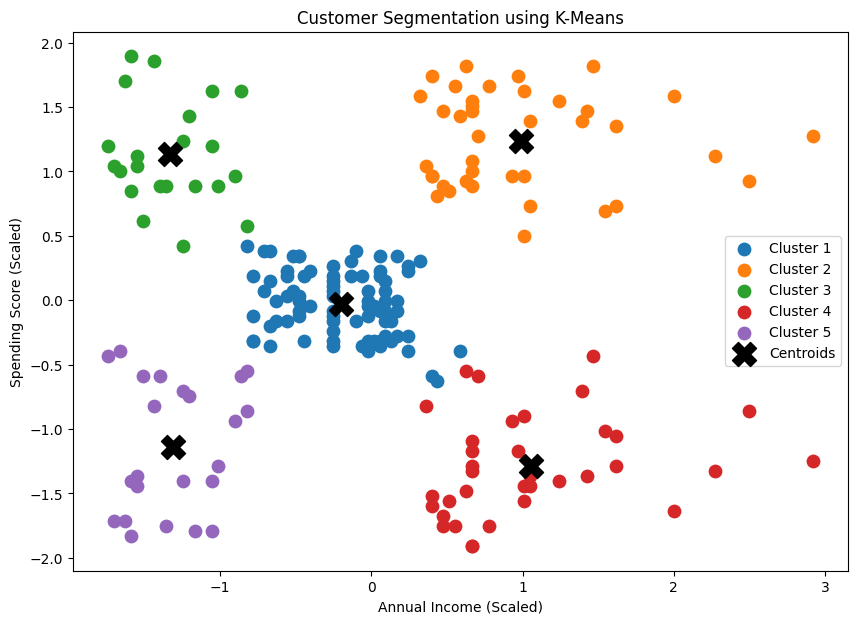

In [12]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_scaled[clusters == 0, 0],
    X_scaled[clusters == 0, 1],
    s=80,
    label='Cluster 1'
)

plt.scatter(
    X_scaled[clusters == 1, 0],
    X_scaled[clusters == 1, 1],
    s=80,
    label='Cluster 2'
)

plt.scatter(
    X_scaled[clusters == 2, 0],
    X_scaled[clusters == 2, 1],
    s=80,
    label='Cluster 3'
)

plt.scatter(
    X_scaled[clusters == 3, 0],
    X_scaled[clusters == 3, 1],
    s=80,
    label='Cluster 4'
)

plt.scatter(
    X_scaled[clusters == 4, 0],
    X_scaled[clusters == 4, 1],
    s=80,
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

Evaluate Model using Silhouette Score

In [13]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.555


Analyze Cluster Counts

In [14]:
cluster_counts = df['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


Cluster-wise Summary

In [15]:
cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [16]:
df.to_csv('Customer_Segmentation_Output.csv', index=False)

print("File saved successfully!")

File saved successfully!


In [17]:
print(df.head(20))

    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   19                  15                      39   
1            2    Male   21                  15                      81   
2            3  Female   20                  16                       6   
3            4  Female   23                  16                      77   
4            5  Female   31                  17                      40   
5            6  Female   22                  17                      76   
6            7  Female   35                  18                       6   
7            8  Female   23                  18                      94   
8            9    Male   64                  19                       3   
9           10  Female   30                  19                      72   
10          11    Male   67                  19                      14   
11          12  Female   35                  19                      99   
12          13  Female   

In [18]:
df.to_csv("Customer_Segmentation_Output.csv", index=False)

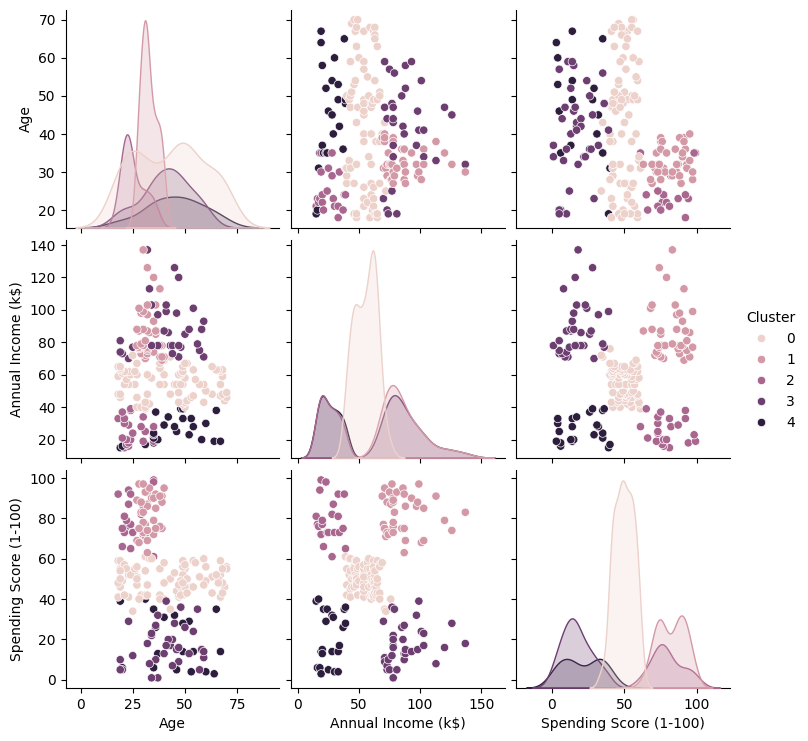

In [19]:
sns.pairplot(
    df,
    vars=['Age','Annual Income (k$)','Spending Score (1-100)'],
    hue='Cluster'
)

plt.show()

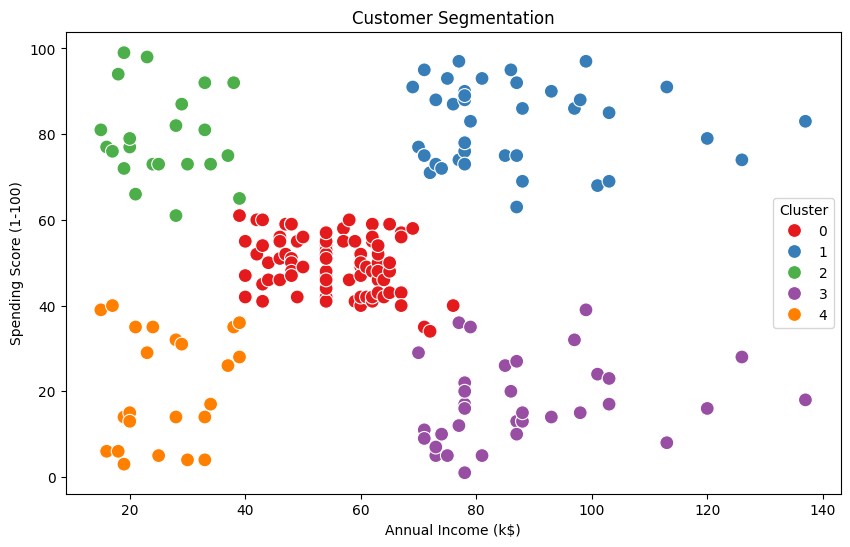

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Customer Segmentation")
plt.show()